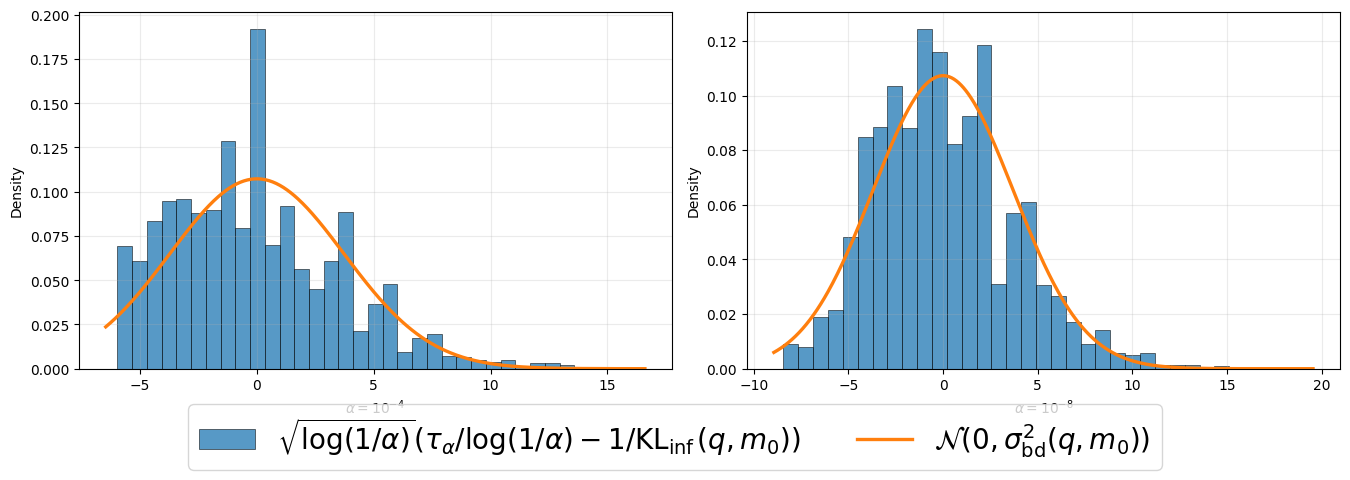

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


# ============================================================
# A) Bernoulli KL: d(p, q)
# ============================================================
def kl_bernoulli(p: float, q: float, eps: float = 1e-12) -> float:
    p = float(np.clip(p, eps, 1.0 - eps))
    q = float(np.clip(q, eps, 1.0 - eps))
    return p * np.log(p / q) + (1.0 - p) * np.log((1.0 - p) / (1.0 - q))


def dprime_bernoulli(p: float, q: float, eps: float = 1e-12) -> float:
    p = float(np.clip(p, eps, 1.0 - eps))
    q = float(np.clip(q, eps, 1.0 - eps))
    return np.log(p * (1.0 - q) / (q * (1.0 - p)))


# ============================================================
# B) Population quantities (analytic for Bernoulli(p))
# ============================================================
def population_quantities_bernoulli(p: float, m0: float) -> dict:
    L = kl_bernoulli(p, m0)
    dp = dprime_bernoulli(p, m0)
    sigma2 = (dp ** 2) * p * (1.0 - p)
    sigma2_bd = sigma2 / (L ** 3)
    return {
        "p": float(p),
        "m0": float(m0),
        "L": float(L),
        "dprime": float(dp),
        "sigma2": float(sigma2),
        "sigma2_bd": float(sigma2_bd),
        "sigma_bd": float(np.sqrt(sigma2_bd)),
    }


# ============================================================
# C) Stopping rule and beta(n, alpha)
# ============================================================
def beta(n: int, alpha: float) -> float:
    return np.log(1 / alpha)


def compute_tau_alpha_bernoulli(p: float, m0: float, alpha: float, n_max: int, seed: int = 0) -> int:
    rng = np.random.default_rng(seed)
    X = rng.binomial(n=1, p=p, size=n_max)

    s = 0.0
    for n in range(1, n_max + 1):
        s += X[n - 1]
        mu_hat = s / n
        L_n = kl_bernoulli(mu_hat, m0)
        if n * L_n >= beta(n, alpha):
            return n
    return n_max + 1


def simulate_tau_distribution_bernoulli(p: float, m0: float, alpha: float, n_paths: int, n_max: int, base_seed: int = 123):
    taus = np.empty(n_paths, dtype=int)
    for r in range(n_paths):
        taus[r] = compute_tau_alpha_bernoulli(p, m0, alpha, n_max=n_max, seed=base_seed + r)
    return taus


# ============================================================
# D) Plot helpers (match your example: legend centered below; xlabel shows alpha)
# ============================================================
def alpha_to_latex(a: float) -> str:
    # Nice LaTeX like 10^{-8} when possible
    if a <= 0:
        return r"0"
    e = int(np.round(np.log10(a)))
    if np.isclose(a, 10.0 ** e):
        return rf"10^{{{e}}}"
    # fallback
    return rf"{a:.2g}"


def plot_tau_clt_overlay(
    taus: np.ndarray,
    alpha: float,
    L_true: float,
    sigma2_bd: float,
    n_max: int,
    ax=None,
):
    b = np.log(1.0 / alpha)

    taus_use = taus[taus <= n_max]
    Z = np.sqrt(b) * (taus_use / b - 1.0 / L_true)

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(7.2, 4.6))

    # histogram (blue)
    ax.hist(
        Z,
        bins= 35,
        density=True,
        alpha=0.75,
        edgecolor="black",
        linewidth=0.5,
        label=rf"$\sqrt{{\log(1/\alpha)}}\left(\tau_\alpha/\log(1/\alpha)-1/\mathrm{{KL}}_{{\inf}}(q,m_0)\right)$",
    )

    # normal overlay (orange)
    xs = np.linspace(np.min(Z) - 0.5, np.max(Z) + 0.5, 450)
    ax.plot(
        xs,
        norm.pdf(xs, loc=0.0, scale=np.sqrt(sigma2_bd)),
        linewidth=2.4,
        label=rf"$\mathcal{{N}}(0,\sigma^2_{{\rm bd}}(q,m_0))$",
    )

    # ---- styling to match your sample figure ----
    ax.set_ylabel("Density")          # keep vertical "Density" like the example
    ax.set_xlabel(rf"$\alpha = {alpha_to_latex(alpha)}$")  # ONLY alpha on x-axis
    ax.grid(True, alpha=0.25)

    # IMPORTANT: no per-axis legend (we'll add one global legend below)
    return ax


# ============================================================
# E) Run
# ============================================================
if __name__ == "__main__":
    m0 = 0.2
    p = 0.6
    alphas = [1e-4, 1e-8]  # add more, e.g. [1e-2, 1e-3, 1e-4]

    n_paths = 5000
    n_max = 2_000_000

    pop = population_quantities_bernoulli(p, m0)

    fig, axes = plt.subplots(1, len(alphas), figsize=(6.8 * len(alphas), 4.8))
    if len(alphas) == 1:
        axes = [axes]

    for j, a in enumerate(alphas):
        taus = simulate_tau_distribution_bernoulli(
            p=p, m0=m0, alpha=a, n_paths=n_paths, n_max=n_max, base_seed=12345 + 1000 * j
        )
        plot_tau_clt_overlay(
            taus, a, L_true=pop["L"], sigma2_bd=pop["sigma2_bd"], n_max=n_max, ax=axes[j]
        )

    # ---- one shared legend centered below (like your attached figure) ----
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=2,
        frameon=True,
        fontsize=20,
        bbox_to_anchor=(0.5, -0.02),
    )

    # leave room at the bottom for the legend
    fig.tight_layout()
    fig.subplots_adjust(bottom=0.22)

    plt.show()


In [ ]:
fig.savefig("clt_stopping_relaxed_beta.pdf", bbox_inches="tight")


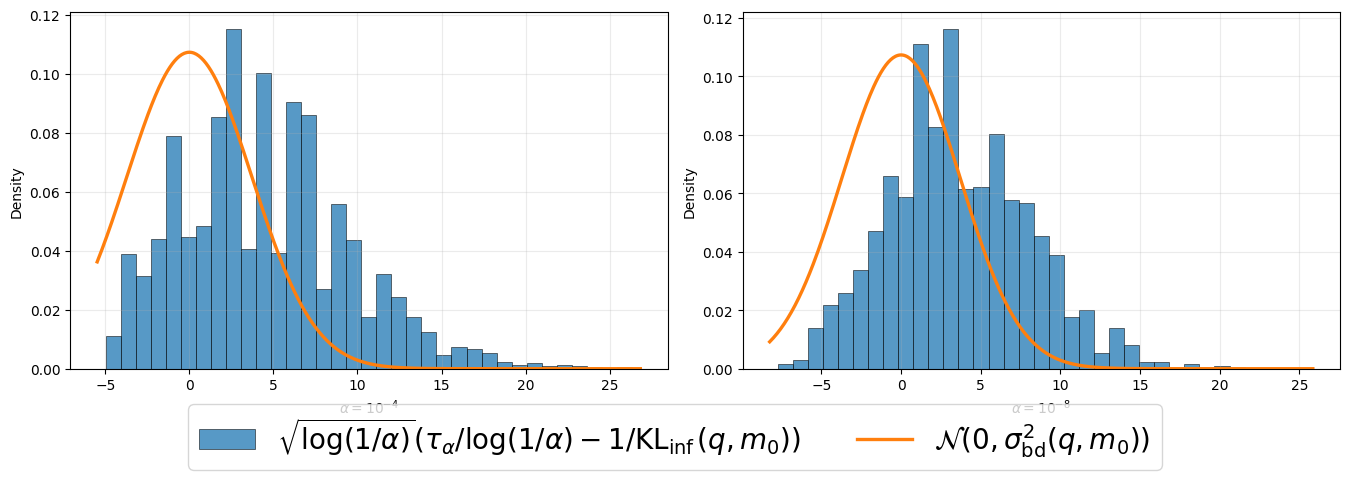

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


# ============================================================
# A) Bernoulli KL: d(p, q)
# ============================================================
def kl_bernoulli(p: float, q: float, eps: float = 1e-12) -> float:
    p = float(np.clip(p, eps, 1.0 - eps))
    q = float(np.clip(q, eps, 1.0 - eps))
    return p * np.log(p / q) + (1.0 - p) * np.log((1.0 - p) / (1.0 - q))


def dprime_bernoulli(p: float, q: float, eps: float = 1e-12) -> float:
    p = float(np.clip(p, eps, 1.0 - eps))
    q = float(np.clip(q, eps, 1.0 - eps))
    return np.log(p * (1.0 - q) / (q * (1.0 - p)))


# ============================================================
# B) Population quantities (analytic for Bernoulli(p))
# ============================================================
def population_quantities_bernoulli(p: float, m0: float) -> dict:
    L = kl_bernoulli(p, m0)
    dp = dprime_bernoulli(p, m0)
    sigma2 = (dp ** 2) * p * (1.0 - p)
    sigma2_bd = sigma2 / (L ** 3)
    return {
        "p": float(p),
        "m0": float(m0),
        "L": float(L),
        "dprime": float(dp),
        "sigma2": float(sigma2),
        "sigma2_bd": float(sigma2_bd),
        "sigma_bd": float(np.sqrt(sigma2_bd)),
    }


# ============================================================
# C) Stopping rule and beta(n, alpha)
# ============================================================
def beta(n: int, alpha: float) -> float:
    return 1.0 + np.log(2.0 * (1.0 + n) / alpha)


def compute_tau_alpha_bernoulli(p: float, m0: float, alpha: float, n_max: int, seed: int = 0) -> int:
    rng = np.random.default_rng(seed)
    X = rng.binomial(n=1, p=p, size=n_max)

    s = 0.0
    for n in range(1, n_max + 1):
        s += X[n - 1]
        mu_hat = s / n
        L_n = kl_bernoulli(mu_hat, m0)
        if n * L_n >= beta(n, alpha):
            return n
    return n_max + 1


def simulate_tau_distribution_bernoulli(p: float, m0: float, alpha: float, n_paths: int, n_max: int, base_seed: int = 123):
    taus = np.empty(n_paths, dtype=int)
    for r in range(n_paths):
        taus[r] = compute_tau_alpha_bernoulli(p, m0, alpha, n_max=n_max, seed=base_seed + r)
    return taus


# ============================================================
# D) Plot helpers (match your example: legend centered below; xlabel shows alpha)
# ============================================================
def alpha_to_latex(a: float) -> str:
    # Nice LaTeX like 10^{-8} when possible
    if a <= 0:
        return r"0"
    e = int(np.round(np.log10(a)))
    if np.isclose(a, 10.0 ** e):
        return rf"10^{{{e}}}"
    # fallback
    return rf"{a:.2g}"


def plot_tau_clt_overlay(
    taus: np.ndarray,
    alpha: float,
    L_true: float,
    sigma2_bd: float,
    n_max: int,
    ax=None,
):
    b = np.log(1.0 / alpha)

    taus_use = taus[taus <= n_max]
    Z = np.sqrt(b) * (taus_use / b - 1.0 / L_true)

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(7.2, 4.6))

    #bin_width = 0.5
    #bins = np.arange(
     #   np.floor(Z.min() / bin_width) * bin_width,
     #   np.ceil(Z.max()  / bin_width) * bin_width + bin_width,
      #  bin_width,
    #)

    # histogram (blue)
    ax.hist(
        Z,
        bins=35,
        #bins=bins,
        density=True,
        alpha=0.75,
        edgecolor="black",
        linewidth=0.5,
        label=rf"$\sqrt{{\log(1/\alpha)}}\left(\tau_\alpha/\log(1/\alpha)-1/\mathrm{{KL}}_{{\inf}}(q,m_0)\right)$",
    )

    # normal overlay (orange)
    xs = np.linspace(np.min(Z) - 0.5, np.max(Z) + 0.5, 450)
    ax.plot(
        xs,
        norm.pdf(xs, loc=0.0, scale=np.sqrt(sigma2_bd)),
        linewidth=2.4,
        label=rf"$\mathcal{{N}}(0,\sigma^2_{{\rm bd}}(q,m_0))$",
    )

    # ---- styling to match your sample figure ----
    ax.set_ylabel("Density")          # keep vertical "Density" like the example
    ax.set_xlabel(rf"$\alpha = {alpha_to_latex(alpha)}$")  # ONLY alpha on x-axis
    ax.grid(True, alpha=0.25)

    # IMPORTANT: no per-axis legend (we'll add one global legend below)
    return ax


# ============================================================
# E) Run
# ============================================================
if __name__ == "__main__":
    m0 = 0.2
    p = 0.6
    alphas = [1e-4, 1e-8]  # add more, e.g. [1e-2, 1e-3, 1e-4]

    n_paths = 5000
    n_max = 2_000_000

    pop = population_quantities_bernoulli(p, m0)

    fig, axes = plt.subplots(1, len(alphas), figsize=(6.8 * len(alphas), 4.8))
    if len(alphas) == 1:
        axes = [axes]

    for j, a in enumerate(alphas):
        taus = simulate_tau_distribution_bernoulli(
            p=p, m0=m0, alpha=a, n_paths=n_paths, n_max=n_max, base_seed=12345 + 1000 * j
        )
        plot_tau_clt_overlay(
            taus, a, L_true=pop["L"], sigma2_bd=pop["sigma2_bd"], n_max=n_max, ax=axes[j]
        )

    # ---- one shared legend centered below (like your attached figure) ----
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=2,
        frameon=True,
        fontsize=20,
        bbox_to_anchor=(0.5, -0.02),
    )

    # leave room at the bottom for the legend
    fig.tight_layout()
    fig.subplots_adjust(bottom=0.22)

    plt.show()


In [ ]:
fig.savefig("clt_stopping_beta.pdf", bbox_inches="tight")


In [ ]:
#### NOw we run the code for real world data set in the cell below. [post rebuttal]

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import fsolve, root_scalar


# ============================================================
# A) Empirical KL_inf via dual definition (Code-1 style)
#    KL_inf(X_1:n, m0) = max_{lambda in [0, 1/(1-m0))} mean log(1 - lambda*(X - m0))
# ============================================================
def compute_kl_inf_empirical(
    X: np.ndarray,
    m0: float,
    clip_upper: float = 0.9999,
    boundary_factor: float = 0.9999,
    eps: float = 1e-12,
) -> tuple:
    """
    Returns (L_hat, lambda_hat) using dual definition:
      Xi = mean((1-m0) / (1 - X_clipped))
      if Xi < 1  -> boundary solution
      else       -> solve Psi(lambda) = 0 via Brent / fsolve
    L_hat = mean( log(1 - lambda_hat * (X - m0)) )
    """
    X = np.asarray(X, dtype=float)
    lambda_max = 1.0 / (1.0 - m0)
    upper = lambda_max * (1.0 - eps)

    Xi = float(np.mean((1.0 - m0) / (1.0 - np.clip(X, 0.0, clip_upper))))

    if Xi < 1.0:
        # boundary case
        lam_hat = lambda_max * boundary_factor
    else:
        # interior: solve Psi(lambda) = -mean((X - m0) / (1 - lambda*(X - m0))) = 0
        def psi(lam: float) -> float:
            denom = 1.0 - lam * (X - m0)
            if np.any(denom <= 0):
                return 1e10
            return float(-np.mean((X - m0) / denom))

        lam_hat = None
        try:
            psi0  = psi(0.0)
            psihi = psi(upper)
            if np.isfinite(psi0) and np.isfinite(psihi) and (psi0 * psihi < 0):
                sol = root_scalar(psi, bracket=(0.0, upper), method="brentq")
                if sol.converged:
                    lam_hat = float(sol.root)
        except Exception:
            lam_hat = None

        if lam_hat is None:
            try:
                guess   = min(0.5 * lambda_max, upper * 0.5)
                lam_hat = float(fsolve(lambda t: psi(float(t)), x0=guess, maxfev=2000)[0])
            except Exception:
                lam_hat = lambda_max * boundary_factor

        if (lam_hat is None) or (lam_hat <= 0.0) or (lam_hat >= upper) or (not np.isfinite(lam_hat)):
            lam_hat = lambda_max * boundary_factor

    arg = 1.0 - lam_hat * (X - m0)
    if np.any(arg <= 0):
        return float("-inf"), lam_hat

    L_hat = float(np.mean(np.log(arg)))
    return L_hat, lam_hat


# ============================================================
# B) Population quantities via Monte Carlo on real data pool
#    L      = KL_inf(q, m0)   estimated on large MC sample
#    sigma2 = Var_q( log(1 - lambda*(X - m0)) )
#    sigma2_bd = sigma2 / L^3
# ============================================================
def compute_population_quantities(X_pool: np.ndarray, m0: float, n_mc: int = 400_000, seed: int = 123) -> dict:
    rng   = np.random.default_rng(seed)
    X_mc  = rng.choice(X_pool, size=n_mc, replace=True)

    L, lam_star = compute_kl_inf_empirical(X_mc, m0)

    ell_vals  = np.log(1.0 - lam_star * (X_mc - m0))
    sigma2    = float(np.var(ell_vals, ddof=0))
    sigma2_bd = sigma2 / (L ** 3)

    return {
        "L":          L,
        "lambda_star": lam_star,
        "sigma2":     sigma2,
        "sigma2_bd":  sigma2_bd,
        "sigma_bd":   float(np.sqrt(sigma2_bd)),
    }


# ============================================================
# C) Stopping rule: tau_alpha = first n s.t. n*KL_inf(X_1:n, m0) >= log(1/alpha)
#    Paths are bootstrapped from the real data pool.
# ============================================================
def simulate_tau_distribution(
    X_pool:   np.ndarray,
    m0:       float,
    alpha:    float,
    n_paths:  int,
    n_max:    int,
    base_seed: int = 42,
) -> np.ndarray:
    rng  = np.random.default_rng(base_seed)
    b    = np.log(1.0 / alpha)
    taus = np.empty(n_paths, dtype=int)

    for r in range(n_paths):
        xs  = rng.choice(X_pool, size=n_max, replace=True)
        tau = n_max + 1
        for n in range(1, n_max + 1):
            L_hat, _ = compute_kl_inf_empirical(xs[:n], m0)
            if n * L_hat >= b:
                tau = n
                break
        taus[r] = tau

    return taus


# ============================================================
# D) Plot
# ============================================================
def alpha_to_latex(a: float) -> str:
    e = int(np.round(np.log10(a)))
    if np.isclose(a, 10.0 ** e):
        return rf"10^{{{e}}}"
    return rf"{a:.2g}"


def plot_tau_clt_overlay(taus, alpha, L_true, sigma2_bd, n_max, ax=None):
    b        = np.log(1.0 / alpha)
    taus_use = taus[taus <= n_max]
    Z        = np.sqrt(b) * (taus_use / b - 1.0 / L_true)

    if ax is None:
        _, ax = plt.subplots(figsize=(7.2, 4.6))

    ax.hist(
        Z,
        bins=13,
        density=True,
        alpha=0.75,
        edgecolor="black",
        linewidth=0.5,
        label=(
            r"$\sqrt{\log(1/\alpha)}"
            r"\left(\tau_\alpha/\log(1/\alpha)-1/\mathrm{KL}_{\inf}(\hat{q},m_0)\right)$"
        ),
    )

    xs = np.linspace(Z.min() - 0.5, Z.max() + 0.5, 450)
    ax.plot(
        xs,
        norm.pdf(xs, loc=0.0, scale=np.sqrt(sigma2_bd)),
        linewidth=2.4,
        label=r"$\mathcal{N}(0,\hat{\sigma}^2_{\rm bd}(q,m_0))$",
    )
    ax.grid(True, alpha=0.25)
    ax.set_ylabel("Density", fontsize=20)
    ax.set_xlabel(rf"$\alpha = {alpha_to_latex(alpha)}$", fontsize=20)
    ax.tick_params(axis='both', labelsize=20)
    return ax


# ============================================================
# E) Main  — update file path if needed
# ============================================================
if __name__ == "__main__":

    # --- Upload the Excel file ---
    from google.colab import files
    uploaded = files.upload()

    # --- load & scale to [0, 1] ---
    df    = pd.read_excel("icml.xlsx")          # <-- update path if needed
    X_raw = df["Arm_1"].values.astype(float)
    X     = X_raw / X_raw.max()

    # --- parameters ---
    m0      = 0.5
    alpha   = 1e-4
    n_paths = 3000
    n_max   = 10_000

    # --- population quantities (MC on full data pool) ---
    print("Computing population quantities ...")
    pop = compute_population_quantities(X, m0, n_mc=400_000, seed=123)
    print(f"  L          = {pop['L']:.6f}")
    print(f"  lambda*    = {pop['lambda_star']:.6f}")
    print(f"  sigma2     = {pop['sigma2']:.6f}")
    print(f"  sigma2_bd  = {pop['sigma2_bd']:.6f}")

    # --- simulate stopping times ---
    print(f"\nSimulating alpha={alpha:.0e}, {n_paths} paths ...")
    taus = simulate_tau_distribution(
        X_pool=X, m0=m0, alpha=alpha,
        n_paths=n_paths, n_max=n_max, base_seed=12345,
    )
    stopped = (taus <= n_max).sum()
    print(f"  Stopped : {stopped}/{n_paths}")
    print(f"  Mean tau: {taus[taus <= n_max].mean():.1f}")
    print(f"  Med  tau: {np.median(taus[taus <= n_max]):.0f}")

    # --- plot ---
    fig, ax = plt.subplots(figsize=(7.2, 4.8))
    plot_tau_clt_overlay(taus, alpha, L_true=pop["L"], sigma2_bd=pop["sigma2_bd"], n_max=n_max, ax=ax)

    handles, labels = ax.get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc="lower center",
        ncol=2,
        frameon=True,
        fontsize=20,
        bbox_to_anchor=(0.5, -0.08),
    )
    fig.tight_layout()
    fig.subplots_adjust(bottom=0.22)
    plt.savefig("real_data_stopping_time.png", dpi=150, bbox_inches="tight")
    plt.show()

Saving icml.xlsx to icml.xlsx


In [ ]:
### next cell is the addition of ci of stopping time on the bernoilli experment [post rebuttal]


alpha = 1e-04
  Empirical  95% CI for tau: [6.0, 50.0]
  Single-path 95% CI for tau: [2.0,  41.0]  (L_hat=0.4280, sigma2_bd_hat=10.7579)

alpha = 1e-08
  Empirical  95% CI for tau: [22.0, 84.0]
  Single-path 95% CI for tau: [11.9,  49.0]  (L_hat=0.6045, sigma2_bd_hat=4.8485)


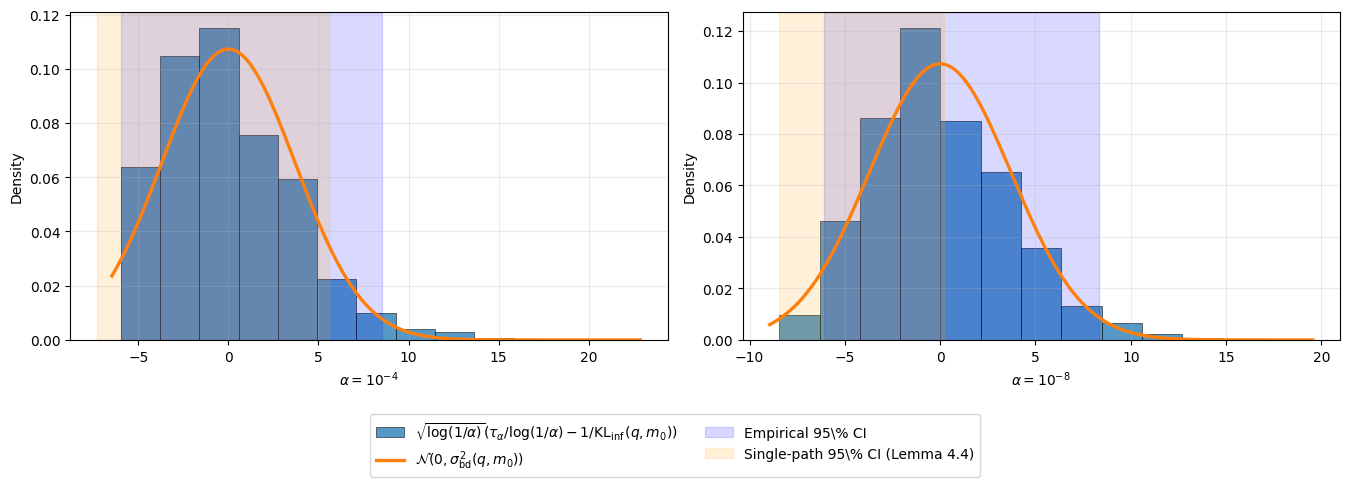

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


# ============================================================
# A) Bernoulli KL: d(p, q)
# ============================================================
def kl_bernoulli(p: float, q: float, eps: float = 1e-12) -> float:
    p = float(np.clip(p, eps, 1.0 - eps))
    q = float(np.clip(q, eps, 1.0 - eps))
    return p * np.log(p / q) + (1.0 - p) * np.log((1.0 - p) / (1.0 - q))


def dprime_bernoulli(p: float, q: float, eps: float = 1e-12) -> float:
    p = float(np.clip(p, eps, 1.0 - eps))
    q = float(np.clip(q, eps, 1.0 - eps))
    return np.log(p * (1.0 - q) / (q * (1.0 - p)))


# ============================================================
# B) Population quantities (analytic for Bernoulli(p))
# ============================================================
def population_quantities_bernoulli(p: float, m0: float) -> dict:
    L = kl_bernoulli(p, m0)
    dp = dprime_bernoulli(p, m0)
    sigma2 = (dp ** 2) * p * (1.0 - p)
    sigma2_bd = sigma2 / (L ** 3)
    return {
        "p": float(p),
        "m0": float(m0),
        "L": float(L),
        "dprime": float(dp),
        "sigma2": float(sigma2),
        "sigma2_bd": float(sigma2_bd),
        "sigma_bd": float(np.sqrt(sigma2_bd)),
    }


# ============================================================
# C) Stopping rule — now also returns observations up to tau
#    for the first path (needed for single-path CI)
# ============================================================
def beta(n: int, alpha: float) -> float:
    return np.log(1 / alpha)


def compute_tau_alpha_bernoulli(
    p: float, m0: float, alpha: float, n_max: int, seed: int = 0,
    return_obs: bool = False,
):
    rng = np.random.default_rng(seed)
    X = rng.binomial(n=1, p=p, size=n_max)

    s = 0.0
    for n in range(1, n_max + 1):
        s += X[n - 1]
        mu_hat = s / n
        L_n = kl_bernoulli(mu_hat, m0)
        if n * L_n >= beta(n, alpha):
            if return_obs:
                return n, X[:n]
            return n
    if return_obs:
        return n_max + 1, X
    return n_max + 1


def simulate_tau_distribution_bernoulli(
    p: float, m0: float, alpha: float, n_paths: int, n_max: int, base_seed: int = 123
):
    taus = np.empty(n_paths, dtype=int)
    # store first path observations for single-path CI
    tau0, X0 = compute_tau_alpha_bernoulli(
        p, m0, alpha, n_max=n_max, seed=base_seed, return_obs=True
    )
    taus[0] = tau0
    for r in range(1, n_paths):
        taus[r] = compute_tau_alpha_bernoulli(p, m0, alpha, n_max=n_max, seed=base_seed + r)
    return taus, X0


# ============================================================
# NEW: CI-1 — Empirical 95% CI from the histogram of rescaled tau
#      Simply the 2.5th and 97.5th percentiles of Z
# ============================================================
def empirical_ci_95(taus: np.ndarray, alpha: float, L_true: float, n_max: int):
    """
    95% CI for tau_alpha from the empirical distribution of the
    rescaled stopping times Z = sqrt(b)*(tau/b - 1/L).

    Returns (ci_lo, ci_hi) on the original tau scale.
    """
    b        = np.log(1.0 / alpha)
    taus_use = taus[taus <= n_max]
    Z        = np.sqrt(b) * (taus_use / b - 1.0 / L_true)

    z_lo, z_hi = np.percentile(Z, [2.5, 97.5])

    # back-transform to tau scale: tau = b*(1/L + z/sqrt(b))
    tau_lo = b * (1.0 / L_true + z_lo / np.sqrt(b))
    tau_hi = b * (1.0 / L_true + z_hi / np.sqrt(b))

    return tau_lo, tau_hi, z_lo, z_hi


# ============================================================
# NEW: CI-2 — Single-path 95% CI via consistent estimator of
#      asymptotic variance (inspired by Lemma 4.4)
#
#  From ONE path X_1,...,X_tau we estimate:
#    mu_hat   = sample mean
#    L_hat    = kl_bernoulli(mu_hat, m0)          consistent for L
#    d_hat    = d'(mu_hat, m0)
#    sigma2_hat = d_hat^2 * mu_hat*(1-mu_hat)     consistent for sigma^2
#    sigma2_bd_hat = sigma2_hat / L_hat^3          consistent for sigma^2_bd
#
#  CLT: sqrt(b)*(tau/b - 1/L) -> N(0, sigma2_bd)
#  =>  tau ~ b/L +/- z_{0.975} * sigma_bd * sqrt(b)
# ============================================================
def single_path_ci_95(X_obs: np.ndarray, m0: float, alpha: float):
    """
    95% asymptotically valid CI for tau_alpha from a single
    observed path X_obs = X_1, ..., X_{tau}.

    Returns (ci_lo, ci_hi) on the tau scale,
    and the estimated (L_hat, sigma2_bd_hat).
    """
    b       = np.log(1.0 / alpha)
    z975    = norm.ppf(0.975)                        # 1.96

    mu_hat  = float(np.mean(X_obs))
    L_hat   = kl_bernoulli(mu_hat, m0)
    d_hat   = dprime_bernoulli(mu_hat, m0)

    # consistent estimator of sigma^2 = Var_q[log-likelihood ratio]
    sigma2_hat    = (d_hat ** 2) * mu_hat * (1.0 - mu_hat)
    sigma2_bd_hat = sigma2_hat / (L_hat ** 3)
    sigma_bd_hat  = np.sqrt(sigma2_bd_hat)

    # CI on tau scale
    centre = b / L_hat
    half   = z975 * sigma_bd_hat * np.sqrt(b)

    return centre - half, centre + half, L_hat, sigma2_bd_hat


# ============================================================
# D) Plot helpers
# ============================================================
def alpha_to_latex(a: float) -> str:
    if a <= 0:
        return r"0"
    e = int(np.round(np.log10(a)))
    if np.isclose(a, 10.0 ** e):
        return rf"10^{{{e}}}"
    return rf"{a:.2g}"


def plot_tau_clt_overlay(
    taus: np.ndarray,
    alpha: float,
    L_true: float,
    sigma2_bd: float,
    n_max: int,
    X_first_path: np.ndarray = None,   # observations from first path
    m0: float = None,
    ax=None,
):
    b        = np.log(1.0 / alpha)
    taus_use = taus[taus <= n_max]
    Z        = np.sqrt(b) * (taus_use / b - 1.0 / L_true)

    if ax is None:
        _, ax = plt.subplots(1, 1, figsize=(7.2, 4.6))

    # histogram
    ax.hist(
        Z,
        bins=13,
        density=True,
        alpha=0.75,
        edgecolor="black",
        linewidth=0.5,
        label=rf"$\sqrt{{\log(1/\alpha)}}\left(\tau_\alpha/\log(1/\alpha)-1/\mathrm{{KL}}_{{\inf}}(q,m_0)\right)$",
    )

    # normal overlay
    xs = np.linspace(np.min(Z) - 0.5, np.max(Z) + 0.5, 450)
    ax.plot(
        xs,
        norm.pdf(xs, loc=0.0, scale=np.sqrt(sigma2_bd)),
        linewidth=2.4,
        label=rf"$\mathcal{{N}}(0,\sigma^2_{{\rm bd}}(q,m_0))$",
    )

    # ---- CI-1: empirical 95% CI (vertical shaded band on Z scale) ----
    _, _, z_lo, z_hi = empirical_ci_95(taus, alpha, L_true, n_max)
    ax.axvspan(z_lo, z_hi, alpha=0.15, color="blue",
               label=r"Empirical 95\% CI")

    # ---- CI-2: single-path 95% CI (vertical shaded band on Z scale) ----
    if X_first_path is not None and m0 is not None:
        tau_lo_sp, tau_hi_sp, L_hat, _ = single_path_ci_95(X_first_path, m0, alpha)
        # convert tau CI back to Z scale
        z_lo_sp = np.sqrt(b) * (tau_lo_sp / b - 1.0 / L_true)
        z_hi_sp = np.sqrt(b) * (tau_hi_sp / b - 1.0 / L_true)
        ax.axvspan(z_lo_sp, z_hi_sp, alpha=0.15, color="orange",
                   label=r"Single-path 95\% CI (Lemma 4.4)")

    ax.set_ylabel("Density")
    ax.set_xlabel(rf"$\alpha = {alpha_to_latex(alpha)}$")
    ax.grid(True, alpha=0.25)
    return ax


# ============================================================
# E) Run
# ============================================================
if __name__ == "__main__":
    m0     = 0.2
    p      = 0.6
    alphas = [1e-4, 1e-8]

    n_paths = 10000
    n_max   = 2_000_000

    pop = population_quantities_bernoulli(p, m0)

    fig, axes = plt.subplots(1, len(alphas), figsize=(6.8 * len(alphas), 4.8))
    if len(alphas) == 1:
        axes = [axes]

    for j, a in enumerate(alphas):
        taus, X_first = simulate_tau_distribution_bernoulli(
            p=p, m0=m0, alpha=a, n_paths=n_paths, n_max=n_max,
            base_seed=12345 + 1000 * j,
        )

        # --- print CI summary ---
        tau_lo_emp, tau_hi_emp, _, _ = empirical_ci_95(taus, a, pop["L"], n_max)
        tau_lo_sp,  tau_hi_sp, L_hat, s2bd_hat = single_path_ci_95(X_first, m0, a)

        print(f"\nalpha = {a:.0e}")
        print(f"  Empirical  95% CI for tau: [{tau_lo_emp:.1f}, {tau_hi_emp:.1f}]")
        print(f"  Single-path 95% CI for tau: [{tau_lo_sp:.1f},  {tau_hi_sp:.1f}]"
              f"  (L_hat={L_hat:.4f}, sigma2_bd_hat={s2bd_hat:.4f})")

        plot_tau_clt_overlay(
            taus, a,
            L_true=pop["L"], sigma2_bd=pop["sigma2_bd"],
            n_max=n_max,
            X_first_path=X_first, m0=m0,
            ax=axes[j],
        )

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc="lower center",
        ncol=2,
        frameon=True,
        bbox_to_anchor=(0.5, -0.02),
    )
    fig.tight_layout()
    fig.subplots_adjust(bottom=0.28)
    plt.show()